# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [1]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

In [8]:
numbers = list(range(10))  # список для shuffle

print("ДО set_seed()")
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #1:", numbers)

numbers = list(range(10))
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #2:", numbers)

set_seed()
print("Seed зафіксовано:", SEED)

print("\nПІСЛЯ set_seed(), з set_seed() перед КОЖНИМ викликом")
set_seed()
numbers = list(range(10))
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #1:", numbers)

set_seed()
numbers = list(range(10))
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #2:", numbers)

print("\nПІСЛЯ set_seed(), БЕЗ проміжних викликів")
set_seed()
numbers = list(range(10))
print("randint #1:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #1:", numbers)

numbers = list(range(10))
print("randint #2:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle #2:", numbers)


ДО set_seed()
randint #1: 92
shuffle #1: [5, 1, 9, 0, 2, 4, 7, 3, 6, 8]
randint #2: 44
shuffle #2: [5, 7, 1, 9, 0, 8, 6, 3, 2, 4]
Seed зафіксовано: 42

ПІСЛЯ set_seed(), з set_seed() перед КОЖНИМ викликом
randint #1: 82
shuffle #1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
randint #2: 82
shuffle #2: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]

ПІСЛЯ set_seed(), БЕЗ проміжних викликів
randint #1: 82
shuffle #1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
randint #2: 76
shuffle #2: [4, 3, 2, 9, 5, 1, 7, 8, 0, 6]


**Пояснення.** До виклику `set_seed()` обидва прогони дають різні числа й різні перестановки, а генератор `random` просто продовжує свій внутрішній стан від попереднього виклику, ніхто його не фіксував.

Коли `set_seed(42)` викликається **перед кожною окремою генерацією**, обидва прогони (`#1` і `#2`) повністю збігаються між собою: і `randint`, і `shuffle` повертають однакові значення, бо генератор щоразу "перезапускається" з того самого стану 42.

А коли `set_seed()` викликано **один раз, а потім два виклики йдуть підряд без повторного `set_seed()`**, `#1` і `#2` знову відрізняються один від одного, але вся ця пара в цілому детермінована і повторюється однаково при перезапуску ноутбука. Це і є суть фіксації seed: не "усі числа однакові", а "послідовність чисел відтворювана".

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [10]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [11]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [12]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape
      if zeros_arr is not None
        else None, zeros_arr.dtype
      if zeros_arr is not None
        else None)

print(sevens_arr, sevens_arr.shape
      if sevens_arr is not None
        else None, sevens_arr.dtype
      if sevens_arr is not None
        else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [13]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [14]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)
print("ndim identity:", identity.ndim, " ndim random_ints:", random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]
ndim identity: 2  ndim random_ints: 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [15]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [16]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [17]:
df = pd.DataFrame({
    "name": ["Віктор", "Дмитро", "Максим", "Богдан", "Тетяна", "Артем", "Юлія", "Ірина"],
    "score": [92, 78, 85, 67, 90, 74, 88, 95],
})

top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)


     name  score
7   Ірина     95
0  Віктор     92
4  Тетяна     90
6    Юлія     88
2  Максим     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [19]:
def score_to_grade(score):
    if score >= 90:
        return "A"
    elif score >= 75:
        return "B"
    else:
        return "C"

df["grade"] = df["score"].apply(score_to_grade)
print(df)


     name  score grade
0  Віктор     92     A
1  Дмитро     78     B
2  Максим     85     B
3  Богдан     67     C
4  Тетяна     90     A
5   Артем     74     C
6    Юлія     88     B
7   Ірина     95     A


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [20]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t, zeros_t.shape, zeros_t.dtype)
print(sevens_t, sevens_t.shape, sevens_t.dtype)


tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32
tensor([[7, 7, 7],
        [7, 7, 7]]) torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [21]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [22]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list, from_list.shape, from_list.dtype, from_list.ndim)
print(random_t, random_t.shape, random_t.dtype, random_t.ndim)


tensor([[1, 2],
        [3, 4]]) torch.Size([2, 2]) torch.int64 2
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]]) torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [23]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print("Автоматичний градієнт (x.grad):", x.grad.item())
print("Аналітичний градієнт (2 * n): ", 2 * n)


Автоматичний градієнт (x.grad): 10.0
Аналітичний градієнт (2 * n):  10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [24]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()
    if step % 5 == 0 or step == 19:
        print(f"step {step:2d}  x={x.item():.4f}  loss={loss.item():.4f}")

print(f"x = {x.item():.4f}  (мінімум у x=3)")


step  0  x=0.6000  loss=14.0000
step  5  x=2.2136  loss=5.9664
step 10  x=2.7423  loss=5.1038
step 15  x=2.9156  loss=5.0111
step 19  x=2.9654  loss=5.0019
x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

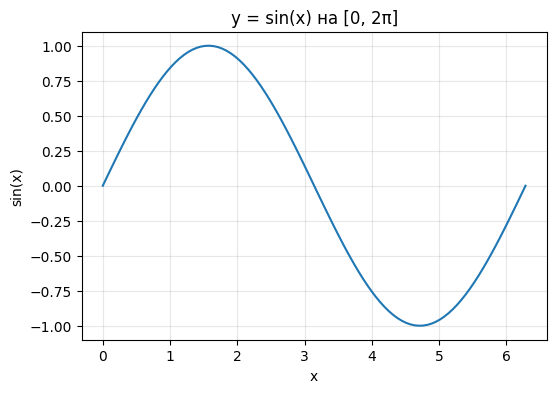

In [25]:
xs = np.linspace(0, 2 * np.pi, 100)

plt.figure(figsize=(6, 4))
plt.plot(xs, np.sin(xs))
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("y = sin(x) на [0, 2π]")
plt.grid(alpha=0.3)
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

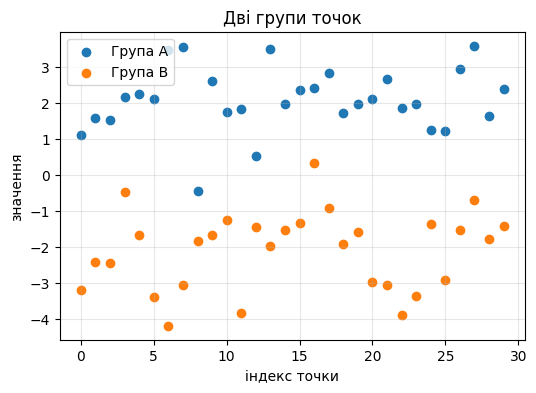

In [26]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.figure(figsize=(6, 4))
plt.scatter(range(len(group_a)), group_a, color="C0", label="Група A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="Група B")
plt.xlabel("індекс точки")
plt.ylabel("значення")
plt.title("Дві групи точок")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [27]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

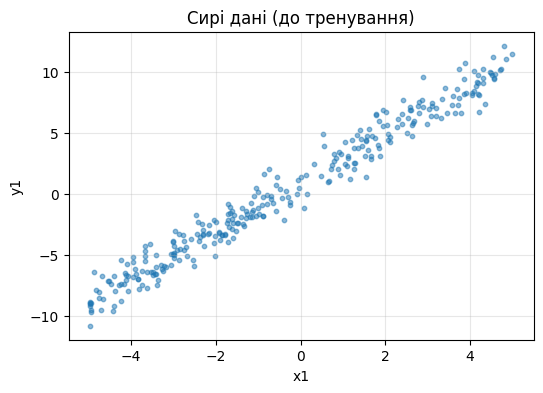

In [29]:
plt.figure(figsize=(6, 4))
plt.scatter(x1.numpy(), y1.numpy(), s=10, alpha=0.5)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [32]:
perm = torch.randperm(TASK1_N)
x1_shuffled = x1[perm]
y1_shuffled = y1[perm]

n_train = int(0.70 * TASK1_N)
n_val = int(0.15 * TASK1_N)
# решту (15%, з округленням) віддаємо test, щоб точно покрити всі TASK1_N точок
n_test = TASK1_N - n_train - n_val

x_train1, y_train1 = x1_shuffled[:n_train], y1_shuffled[:n_train]
x_val1, y_val1 = x1_shuffled[n_train:n_train + n_val], y1_shuffled[n_train:n_train + n_val]
x_test1, y_test1 = x1_shuffled[n_train + n_val:], y1_shuffled[n_train + n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [33]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=16.105141  w=1.7198 (true 2.0)  b=0.9313 (true 1.0)
epoch   30  loss=0.928843  w=1.9580 (true 2.0)  b=0.9466 (true 1.0)
epoch   60  loss=0.928841  w=1.9580 (true 2.0)  b=0.9477 (true 1.0)
epoch   90  loss=0.928841  w=1.9580 (true 2.0)  b=0.9477 (true 1.0)
epoch   99  loss=0.928841  w=1.9580 (true 2.0)  b=0.9477 (true 1.0)


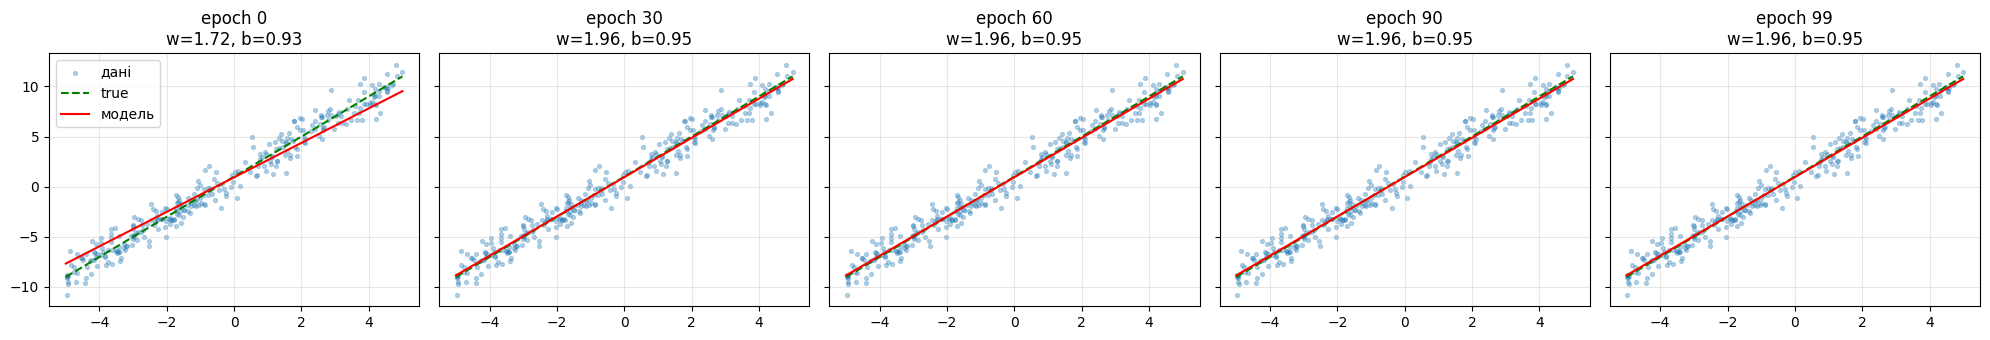

In [34]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Мій сценарій: години сну -> продуктивність за день

Я обираю залежність **кількість годин сну за ніч -> самооцінка продуктивності наступного дня** (за шкалою від 0 до 10).

Закладаю такі параметри:
- $w = 1.1$ - кожна додаткова година сну в середньому піднімає продуктивність приблизно на 1.1 бала. Це узгоджується зі звичайним досвідом: недосип помітно "з'їдає" концентрацію, хоча в реальності залежність швидше насичується після 8-9 годин; для лінійної моделі беремо спрощений робочий діапазон, де таке наближення адекватне.
- $b = -2.0$ - при дуже малому сні (близько 0 годин) базовий рівень продуктивності від'ємний/дуже низький, що логічно: без сну людина функціонує на межі можливостей.
- Діапазон $x$ (годин сну): від 3 до 10 - реалістичний робочий діапазон, де лінійне наближення має сенс (менше 3 і більше 10 годин сну - рідкісні, нетипові випадки, для яких лінійність, ймовірно, вже не тримається).
- Шум $\varepsilon \sim \mathcal{N}(0, 0.8)$ - дещо менший за приклад із лекції, бо самооцінка продуктивності хоч і суб'єктивна, але не цілком випадкова відносно сну.

In [56]:
MY_TRUE_W = 1.1
MY_TRUE_B = -2.0
MY_N = 300
MY_NOISE_STD = 0.8

set_seed()  # той самий seed, щоб генерація теж була відтворюваною

x_sleep = torch.empty(MY_N, 1).uniform_(3, 10)
noise_my = MY_NOISE_STD * torch.randn(MY_N, 1)
y_productivity = MY_TRUE_W * x_sleep + MY_TRUE_B + noise_my

print("x_sleep[:5]:\n", x_sleep[:5])
print("y_productivity[:5]:\n", y_productivity[:5])


x_sleep[:5]:
 tensor([[9.1759],
        [9.4050],
        [5.6800],
        [9.7151],
        [5.7331]])
y_productivity[:5]:
 tensor([[7.6477],
        [7.5709],
        [4.9451],
        [8.6101],
        [4.6295]])


In [57]:
df_my = pd.DataFrame({
    "hours_sleep": x_sleep.squeeze(1).numpy(),
    "productivity": y_productivity.squeeze(1).numpy(),
})

CSV_PATH = os.path.join(ARTIFACT_DIR, "dataset.csv")
df_my.to_csv(CSV_PATH, index=False)

print(f"Збережено {len(df_my)} рядків у {CSV_PATH}")
df_my.head()


Збережено 300 рядків у /content/drive/MyDrive/ai_systems/lab1/dataset.csv


,hours_sleep,productivity
0,9.175885,7.647724
1,9.405027,7.570853
2,5.680046,4.945074
3,9.715139,8.610141
4,5.733138,4.629494


#### Перевикористовувані функції тренування

Виношу спліт даних, тренувальний цикл і оцінку в окремі функції — той самий патерн, що й у Вправах 18-19, тільки узагальнений так, щоб працював з будь-яким `x`/`y`.

In [59]:
def split_train_val_test(x, y, train_frac=0.70, val_frac=0.15, seed: int = SEED):
    """Перемішує (x, y) і ріже на train/val/test у заданих пропорціях."""
    n = x.shape[0]
    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=generator)
    x_shuffled, y_shuffled = x[perm], y[perm]

    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    x_train, y_train = x_shuffled[:n_train], y_shuffled[:n_train]
    x_val, y_val = x_shuffled[n_train:n_train + n_val], y_shuffled[n_train:n_train + n_val]
    x_test, y_test = x_shuffled[n_train + n_val:], y_shuffled[n_train + n_val:]

    return (x_train, y_train), (x_val, y_val), (x_test, y_test)


def train_linear_model(x_train, y_train, x_val, y_val, epochs: int = 100, lr: float = 0.05, verbose: bool = True):
    """Тренує torch.nn.Linear(1, 1) через SGD + MSELoss, повертає модель і історію loss."""
    model = torch.nn.Linear(in_features=1, out_features=1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}

    print_every = max(1, epochs // 10)

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            val_loss = loss_fn(model(x_val), y_val)

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())

        if verbose and (epoch % print_every == 0 or epoch == epochs - 1):
            print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss.item():.4f}  "
                  f"w={model.weight.item():.4f}  b={model.bias.item():.4f}")

    return model, history


def evaluate_model(model, x_test, y_test):
    """Рахує MSE на test і повертає (mse, y_pred)."""
    loss_fn = torch.nn.MSELoss()
    with torch.no_grad():
        y_pred = model(x_test)
        mse = loss_fn(y_pred, y_test).item()
    return mse, y_pred

In [60]:
(x_train_my, y_train_my), (x_val_my, y_val_my), (x_test_my, y_test_my) = split_train_val_test(x_sleep, y_productivity)

print(f"train/val/test: {len(x_train_my)}/{len(x_val_my)}/{len(x_test_my)}")

# x_sleep у діапазоні [3, 10] (не [-5, 5], як у Вправі 19), тож градієнт по w
# масштабується приблизно як x^2 ~ 40-100. При lr=0.05 і 100 епохах це
# призводило до вибуху ваг до nan вже за 10 епох, тому тут lr менший,
# а epochs -- більший, щоб все одно дотренуватись до збіжності.
my_model, my_history = train_linear_model(x_train_my, y_train_my, x_val_my, y_val_my, epochs=2000, lr=0.01)

test_mse, y_test_pred = evaluate_model(my_model, x_test_my, y_test_my)
print(f"\nTest MSE: {test_mse:.4f}")
print(f"Навчені параметри: w={my_model.weight.item():.4f} (true {MY_TRUE_W}), "
      f"b={my_model.bias.item():.4f} (true {MY_TRUE_B})")

train/val/test: 210/45/45
epoch    0  train_loss=29.7995  val_loss=0.6680  w=0.8469  b=-0.7034
epoch  200  train_loss=0.6902  val_loss=0.5426  w=0.9908  b=-1.0745
epoch  400  train_loss=0.6546  val_loss=0.5023  w=1.0286  b=-1.3367
epoch  600  train_loss=0.6380  val_loss=0.4815  w=1.0544  b=-1.5157
epoch  800  train_loss=0.6303  val_loss=0.4704  w=1.0721  b=-1.6380
epoch 1000  train_loss=0.6267  val_loss=0.4643  w=1.0841  b=-1.7215
epoch 1200  train_loss=0.6250  val_loss=0.4608  w=1.0924  b=-1.7785
epoch 1400  train_loss=0.6242  val_loss=0.4587  w=1.0980  b=-1.8175
epoch 1600  train_loss=0.6238  val_loss=0.4574  w=1.1018  b=-1.8441
epoch 1800  train_loss=0.6237  val_loss=0.4567  w=1.1044  b=-1.8622
epoch 1999  train_loss=0.6236  val_loss=0.4561  w=1.1062  b=-1.8746

Test MSE: 0.7278
Навчені параметри: w=1.1062 (true 1.1), b=-1.8746 (true -2.0)


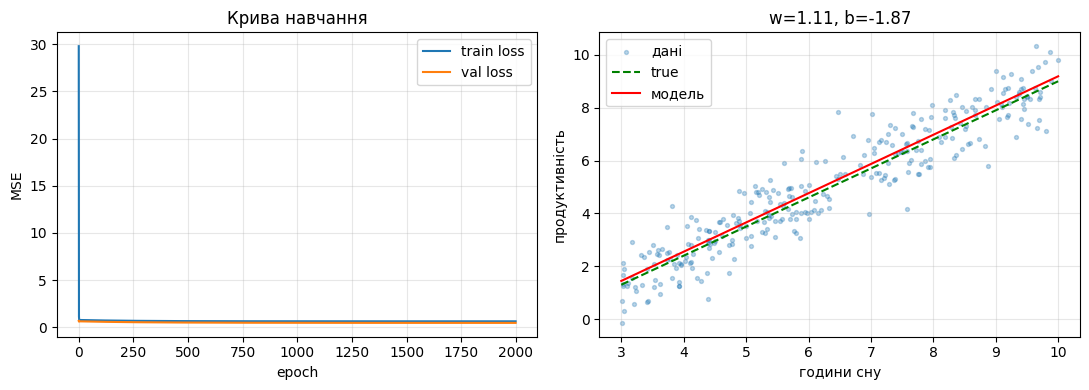

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(my_history["train_loss"], label="train loss")
axes[0].plot(my_history["val_loss"], label="val loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Крива навчання")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Дані + натренована пряма
x_line_my = torch.linspace(3, 10, 100).unsqueeze(1)
with torch.no_grad():
    y_line_my_pred = my_model(x_line_my)
    y_line_my_true = MY_TRUE_W * x_line_my + MY_TRUE_B

axes[1].scatter(x_sleep.numpy(), y_productivity.numpy(), s=8, alpha=0.3, label="дані")
axes[1].plot(x_line_my.numpy(), y_line_my_true.numpy(), "g--", label="true")
axes[1].plot(x_line_my.numpy(), y_line_my_pred.numpy(), "r-", label="модель")
axes[1].set_xlabel("години сну")
axes[1].set_ylabel("продуктивність")
axes[1].set_title(f"w={my_model.weight.item():.2f}, b={my_model.bias.item():.2f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [65]:
MODEL_PATH = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(my_model.state_dict(), MODEL_PATH)

print(f"Модель збережена у: {MODEL_PATH}")

# Швидка перевірка -- завантажуємо у свіжий екземпляр і звіряємо ваги
loaded_model = torch.nn.Linear(in_features=1, out_features=1)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

print("w після завантаження:", loaded_model.weight.item())
print("b після завантаження:", loaded_model.bias.item())
assert loaded_model.weight.item() == my_model.weight.item()
assert loaded_model.bias.item() == my_model.bias.item()
print("Ваги збігаються -- модель збережена і завантажується коректно.")


Модель збережена у: /content/drive/MyDrive/ai_systems/lab1/model.pt
w після завантаження: 1.1062194108963013
b після завантаження: -1.874582290649414
Ваги збігаються -- модель збережена і завантажується коректно.


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [68]:
!pip install -q gradio
import gradio as gr

gradio_model = torch.nn.Linear(in_features=1, out_features=1)
gradio_model.load_state_dict(torch.load(MODEL_PATH))
gradio_model.eval()


def predict_productivity(hours_sleep: float) -> str:
    with torch.no_grad():
        x_input = torch.tensor([[hours_sleep]], dtype=torch.float32)
        pred = gradio_model(x_input).item()
    return f"Прогнозована продуктивність: {pred:.2f} / 10"


demo = gr.Interface(
    fn=predict_productivity,
    inputs=gr.Slider(minimum=0, maximum=12, step=0.5, value=7, label="Годин сну"),
    outputs=gr.Textbox(label="Прогноз"),
    title="Сон -> продуктивність",
    description="Лінійна регресія, натренована у Вправі 20: скільки годин сну -> яка очікувана продуктивність за день.",
)

demo.launch(debug=False)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4882f9c823cf0e3533.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```